# SmartStocks — Notebook 2: Feature Engineering

**Depends on:** `Notebook 01` — `backend/data/prices.parquet` and `backend/data/sector_map.parquet` must exist before running this.

**Goal:** Transform raw price data into a normalized feature matrix that the KNN model (Notebook 3) can consume.

**By the end of this notebook you should be able to answer:**
- What does each feature actually measure, financially?
- What does the distribution of each feature look like across the universe?
- Why does scaling matter for KNN specifically?
- Which features are correlated, and does that concern you?
- Is the output feature matrix plausible — do the numbers make sense for stocks you recognize?

---
## 0. Imports & config

In [ ]:
# TODO: imports — pandas, numpy, matplotlib, sklearn (StandardScaler)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# TODO: load prices.parquet and sector_map.parquet from backend/data/
# Same resolution as Notebook 01 — always backend/data/
_cwd = Path.cwd()
if _cwd.name == "notebooks":
    DATA_DIR = (_cwd.parent / "data").resolve()
elif _cwd.name == "backend":
    DATA_DIR = (_cwd / "data").resolve()
else:
    DATA_DIR = (_cwd / "backend" / "data").resolve()

prices = pd.read_parquet(DATA_DIR / "prices.parquet")
sector_map = pd.read_parquet(DATA_DIR / "sector_map.parquet").set_index("ticker")

# TODO: sanity check — print shape and head of both
print(prices.shape)
print(prices.head())

print(sector_map.shape)
print(sector_map.head())
# TODO: confirm index is DatetimeIndex, no nulls remaining

(501, 750)
Price            Close                                                \
Ticker            AAPL        ABBV        ABNB        ADC        AEM   
Date                                                                   
2024-05-07  180.754974  151.903259  159.809998  54.391838  63.932762   
2024-05-08  181.091919  149.940781  157.899994  53.610867  64.320946   
2024-05-09  182.905411  149.894043  147.050003  54.658283  66.087151   
2024-05-10  181.645187  150.221130  146.320007  55.264687  66.378288   
2024-05-13  184.850372  150.716400  149.130005  55.191177  65.747498   

Price                                                                 ...  \
Ticker            AEP         AFG         ALB       ALLY         AMD  ...   
Date                                                                  ...   
2024-05-07  83.742935  114.563042  126.996254  37.045750  154.429993  ...   
2024-05-08  84.404533  115.804634  125.943985  37.120968  153.619995  ...   
2024-05-09  85.580742  116.

---
## 1. Daily returns

**Why this comes first:** Every feature below is derived from returns, not raw prices. You compute returns once here and reuse them throughout.

**Log returns vs simple returns:**  
Log returns (`ln(P_t / P_{t-1})`) are preferred for statistical work because they're additive over time and more normally distributed than simple returns. Simple returns (`(P_t - P_{t-1}) / P_{t-1}`) are more intuitive but compound in ways that distort rolling calculations.

In [37]:
prices["Close"]["AAPL"]

Date
2024-05-07    180.754974
2024-05-08    181.091919
2024-05-09    182.905411
2024-05-10    181.645187
2024-05-13    184.850372
                 ...    
2026-04-30    271.350006
2026-05-01    280.140015
2026-05-04    276.829987
2026-05-05    284.179993
2026-05-06    287.463013
Name: AAPL, Length: 501, dtype: float64

(500, 150)
(500, 150)


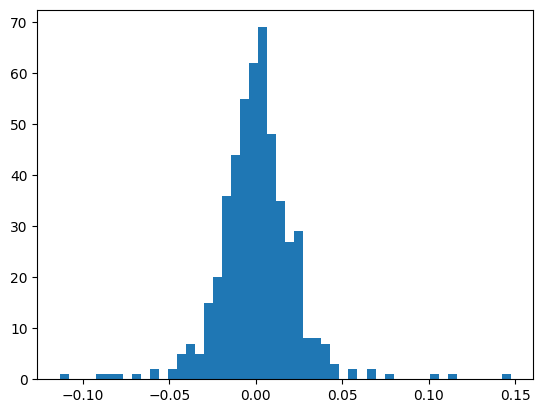

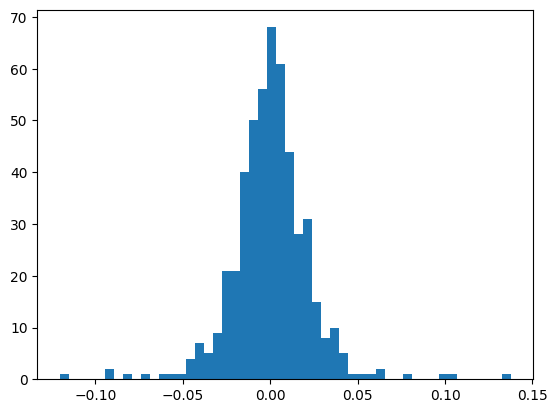

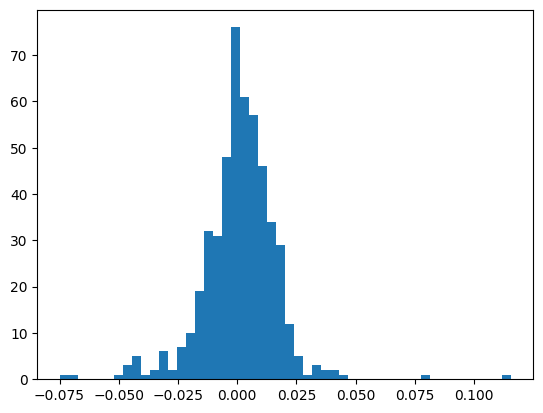

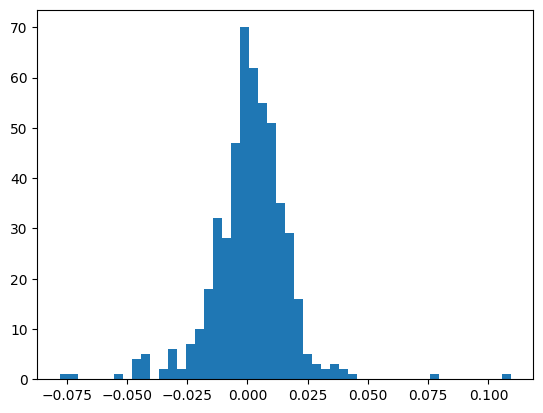

In [ ]:
# TODO: compute daily returns for all tickers


closes = prices["Close"]
# Simple returns 
simple_returns = closes.pct_change().dropna()

# Log returns 
log_returns = np.log(closes / closes.shift(1)).dropna()

# TODO: print shape — should be prices.shape minus 1 row (first row becomes NaN)
print(simple_returns.shape)
print(log_returns.shape)

# TODO: plot the return distribution for 2-3 tickers as histograms
#        — do they look roughly normal? Any fat tails?
plt.hist(simple_returns["META"], bins=50)
plt.show()
plt.hist(log_returns["META"], bins=50)
plt.show()


plt.hist(simple_returns["JPM"], bins=50)
plt.show()
plt.hist(log_returns["JPM"], bins=50)
plt.show()

# look roughly normal
# no fat tails 

# QUESTION TO ANSWER: Do any tickers have return distributions that look suspicious?

---
## 2. Feature 1 — Momentum (30-day)

**What it measures:** How much a stock's price has moved over the past 30 trading days. Positive momentum = upward trend, negative = downward.

**Why it matters for recommendations:** Momentum is one of the most well-documented factors in finance (Jegadeesh & Titman, 1993). Stocks that have performed well recently tend to continue outperforming in the short term. A user who wants growth-oriented picks will implicitly prefer positive momentum.

**Formula:** `(Price_today - Price_30d_ago) / Price_30d_ago`

> **Watch out for:** Momentum is highly sensitive to the window length. 30 days is a reasonable default but you should understand what 10-day vs 60-day momentum looks like — does it change which stocks rank highly?

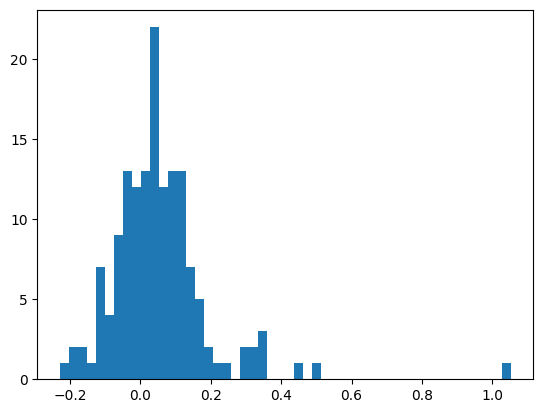

Ticker
AMD     1.052228
QCOM    0.497334
NUE     0.444075
DELL    0.354356
UNH     0.348391
AVGO    0.336643
AMZN    0.326737
ORCL    0.323527
CAT     0.295518
NVO     0.285657
Name: 2026-05-06 00:00:00, dtype: float64
Ticker
COR    -0.228252
NKE    -0.180221
LULU   -0.179621
LMT    -0.157481
AXON   -0.154928
PLTR   -0.135631
HCA    -0.115622
CELH   -0.114710
BSM    -0.108739
ARLP   -0.105575
Name: 2026-05-06 00:00:00, dtype: float64


In [ ]:
# TODO: compute 30-day momentum for all tickers
momentum = closes.pct_change(30).dropna()

# TODO: take the most recent value per ticker (single row — today's momentum)
recent_momentum = momentum.iloc[-1]

# TODO: plot distribution across the universe as a histogram
plt.hist(recent_momentum, bins=50)
plt.show()

# TODO: print the top 10 and bottom 10 tickers by momentum
#        — do the names match your intuition about recent market performance?
top_10_momentum = recent_momentum.nlargest(10)
bottom_10_momentum = recent_momentum.nsmallest(10)

print(top_10_momentum)
print(bottom_10_momentum)

# QUESTION TO ANSWER: Are any momentum values extreme enough to be data errors?

---
## 3. Feature 2 — Volatility (52-week annualised)

**What it measures:** How much a stock's price fluctuates. High volatility = higher risk, higher potential reward. Low volatility = steadier, more predictable.

**Why it matters for recommendations:** This is your primary proxy for risk. A user who says "low risk tolerance" should get low-volatility stocks. A user who says "high risk tolerance" can handle high-volatility names.

**Formula:** Standard deviation of daily log returns × √252  
(Multiplying by √252 annualises it — 252 is the number of trading days in a year)

> **Why annualise?** A daily volatility of 1% sounds small. Annualised, that's ~16%. Annualised numbers are what finance professionals actually talk about — it makes your output interpretable.

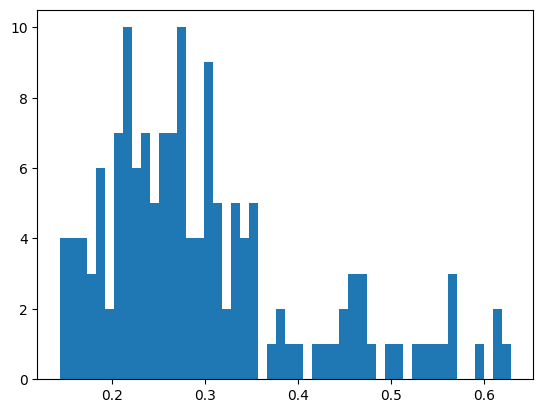

Highest volatility (ticker, sector, annualised vol):

ticker  annualised_vol  index           sector
  CENX        0.628769    115        Materials
   AMD        0.617560      4       Technology
   ALB        0.611415    113        Materials
  ORCL        0.591248      6       Technology
  SHOP        0.567241     13       Technology
    CE        0.566858    118        Materials
  CELH        0.562909     67 Consumer Staples
  SOFI        0.557021     36       Financials
   NVO        0.544097     28       Healthcare
  AXON        0.534630    102      Industrials

Lowest volatility (ticker, sector, annualised vol):

ticker  annualised_vol  index           sector
 BRK-B        0.143739     31       Financials
    RY        0.151157     43       Financials
   WEC        0.152809    135        Utilities
   EPD        0.153316     81           Energy
     O        0.155843    142      Real Estate
    KO        0.160504     63 Consumer Staples
   DTE        0.161480    124        Utilities

In [242]:
# TODO: compute 252-day rolling std of log returns, annualised
volatility = log_returns.rolling(252).std() * np.sqrt(252)

# TODO: take the most recent value per ticker
recent_volatility = volatility.iloc[-1]

# TODO: plot distribution — what's the typical range? Where are the outliers?
plt.hist(recent_volatility, bins=50)
plt.show()

# TODO: print highest and lowest volatility tickers
#        — do Utilities/Consumer Staples land at the low end?
#        — do Tech/Energy land at the high end?
top_10_volatility = recent_volatility.nlargest(10)
bottom_10_volatility = recent_volatility.nsmallest(10)


def volatility_with_sectors(vol_series: pd.Series) -> pd.DataFrame:
    """Join ranked volatility with sector names (sector_map index = ticker)."""
    df = vol_series.rename("annualised_vol").reset_index()
    ticker_col = df.columns[0]
    df = df.rename(columns={ticker_col: "ticker"})
    return df.merge(sector_map.reset_index(), on="ticker", how="left")


print("Highest volatility (ticker, sector, annualised vol):\n")
print(volatility_with_sectors(top_10_volatility).to_string(index=False))
print("\nLowest volatility (ticker, sector, annualised vol):\n")
print(volatility_with_sectors(bottom_10_volatility).to_string(index=False))

# QUESTION TO ANSWER: Does the volatility ranking match your intuition about sector risk?

---
## 4. Feature 3 — P/E Ratio

**What it measures:** Price-to-Earnings ratio. How much investors are paying per dollar of earnings. High P/E = growth expectations priced in (or overvalued). Low P/E = value stock (or a struggling company).

**Why it matters for recommendations:** Users with different investment styles (growth vs value) will have different P/E preferences — even if they don't know it in those terms.

**Source:** yfinance `.info` dict, key `trailingPE`

> **Known messiness:** P/E from yfinance is often missing (companies with negative earnings have no meaningful P/E), stale, or occasionally wildly wrong. You need a strategy for handling this:
> - Negative or missing P/E: impute with sector median, or drop the ticker
> - Extreme outliers (P/E > 500): winsorize — cap at a sensible ceiling
> 
> **Document whatever you decide.** This is a methodology doc moment.

In [ ]:
# TODO: fetch trailingPE for all tickers via yfinance .info
trailing_pe = {}
for ticker in prices.columns.get_level_values(1):
    try:
        info = yf.Ticker(ticker).info
        trailing_pe[ticker] = info.get("trailingPE", None)
    except Exception as e:
        trailing_pe[ticker] = None




#        (this will be slow — consider caching to a dict or JSON)
# TODO: print how many tickers are missing P/E — what % of your universe?
# TODO: plot raw distribution before any cleaning — spot the outliers
# TODO: apply your missing/outlier strategy (winsorize + sector median impute)
# TODO: plot distribution after cleaning — compare to before

# QUESTION TO ANSWER: After cleaning, does the P/E distribution look reasonable?
# Which sectors have the highest median P/E? Does that match expectations?
# (Tech/Consumer Disc usually high, Utilities/Financials usually low)

---
## 5. Feature 4 — Dividend Yield

**What it measures:** Annual dividends paid out as a % of current price. High yield = income-generating stock. Zero yield = growth stock that reinvests earnings.

**Why it matters for recommendations:** This directly maps to a user preference you collected in onboarding (`dividend_pref` 0–1). A retiree wants high yield. A growth investor wants zero.

**Source:** yfinance `.info` key `dividendYield`

> **Note:** Many stocks pay no dividend — `dividendYield` will be `None`. This is valid data (not missing data) — it means 0. Don't impute it, just fill with 0.

In [244]:
# TODO: fetch dividendYield for all tickers
# TODO: fill None with 0 (no dividend ≠ missing data)
# TODO: plot distribution — expect a highly right-skewed distribution
#        (most stocks at 0, a few Utilities/REITs with 3-6%)
# TODO: print highest dividend yield tickers — do they make sense?

# QUESTION TO ANSWER: What % of your universe pays no dividend?
# Which sectors have the highest avg yield?

---
## 6. Feature 5 — Sector encoding

**What it measures:** Which sector the stock belongs to.

**Why it matters for recommendations:** Users pick preferred sectors in onboarding. The KNN engine needs sector as a numeric feature to include sector affinity in the similarity calculation.

**Encoding choice — one-hot vs ordinal:**  
One-hot creates a binary column per sector (10 columns). Ordinal assigns an integer per sector (1 column). For KNN, **one-hot is correct** — ordinal implies an ordering between sectors (Technology > Healthcare > ...) that doesn't exist. One-hot treats all sectors as equidistant.

> **Weight consideration:** With 10 one-hot columns and only 4 other features, sector will numerically dominate the feature space after scaling. Think about whether that's what you want, and note your decision.

In [245]:
# TODO: load sector_map and align it to your ticker universe
# TODO: one-hot encode sectors with pandas get_dummies
# TODO: print the result — should be a DataFrame with 10 binary columns
# TODO: verify every ticker has exactly one 1 across the sector columns

# QUESTION TO ANSWER: Did any tickers in your universe not get a sector assignment?

---
## 7. Assemble the raw feature matrix

Combine all features into a single DataFrame, one row per ticker.

> **Alignment check:** Before concatenating, verify all Series/DataFrames share the same index (ticker symbols). A silent index mismatch will scramble your features without throwing an error — this is one of the most common bugs in pandas feature pipelines.

In [246]:
# TODO: concatenate all features into one DataFrame (tickers as index)
# TODO: print shape — should be (n_tickers, 14) roughly
#        (momentum, volatility, P/E, dividend_yield + 10 sector columns)
# TODO: print .head() and .describe() — inspect every column
# TODO: check for any remaining nulls — print null counts per column
# TODO: drop or impute any remaining nulls before proceeding

# QUESTION TO ANSWER: How many tickers made it into the final matrix?
# Did you lose any compared to Notebook 1? Why?

---
## 8. Check feature distributions & outliers

Before scaling, look at the raw distributions of your continuous features together. You're checking:
- Are any features so skewed that StandardScaler will be misled by outliers?
- Are there any remaining values that look like data errors?

> **P/E is the usual culprit.** Even after winsorizing, check it again here in the context of the full matrix.

In [247]:
# TODO: plot histograms for all 4 continuous features side by side
#        (momentum, volatility, P/E, dividend_yield)
# TODO: print .describe() for those 4 columns
# TODO: identify any remaining outliers that concern you
# TODO: apply any final cleaning before scaling

# QUESTION TO ANSWER: Which feature has the most problematic distribution?
# Does anything still need attention before scaling?

---
## 9. Scale the feature matrix

**Why scaling is mandatory for KNN:**  
KNN measures distance between points. If one feature ranges 0–500 (P/E) and another ranges 0–0.06 (dividend yield), the P/E feature will completely dominate the distance calculation — dividend yield becomes invisible. StandardScaler normalizes each feature to mean=0, std=1 so they contribute equally.

> **Sector columns:** Do NOT scale the one-hot sector columns. They're already 0/1 binary — scaling them would turn 1s into fractional values and distort the sector signal. Scale only the 4 continuous features, then recombine.

In [248]:
# TODO: separate continuous features from sector one-hot columns
# TODO: fit StandardScaler on the continuous features only
# TODO: transform and recombine with sector columns
# TODO: print .describe() on the scaled continuous columns
#        — means should be ~0, stds should be ~1
# TODO: plot distributions before vs after scaling for each continuous feature

# QUESTION TO ANSWER: After scaling, what does a value of +2.0 in the
# volatility column actually mean in plain English?

---
## 10. Feature correlation check

**Why this matters for KNN:** Correlated features effectively double-count the same signal. If momentum and volatility are highly correlated (they sometimes are — high-momentum stocks can also be volatile), then distance calculations are implicitly weighting that shared signal twice.

**What to do about it:** You don't necessarily need to remove correlated features — just be aware of them and note them in your methodology doc. If two features are >0.8 correlated, consider whether both are earning their place.

In [249]:
# TODO: compute correlation matrix on the 4 continuous features (pre-scale is fine)
# TODO: plot as a heatmap with annotations
# TODO: print any pairs with |correlation| > 0.5 and note them

# QUESTION TO ANSWER: Are any features redundant? Would you remove any?
# How does this affect your confidence in the KNN output?

---
## 11. Persist outputs

Save three things:
- The **scaled feature matrix** — input to KNN (Notebook 3)
- The **unscaled feature matrix** — useful for display and interpretation in the app
- The **fitted scaler object** — needed to transform new user preference vectors at inference time

> **Why save the scaler?** When the KNN engine runs in production, it needs to transform a user's ideal-stock vector using the *same* scaler that was fit on training data. If you refit a new scaler later, the distances will be wrong.

In [250]:
# TODO: save scaled feature matrix to backend/data/features_scaled.parquet
# TODO: save unscaled feature matrix to backend/data/features_raw.parquet
# TODO: save the fitted scaler to backend/data/scaler.pkl using joblib
# TODO: reload all three and verify shapes and types match what you saved

# NOTE: add backend/data/scaler.pkl to .gitignore if not already covered

---
## 12. Summary & handoff notes

Fill this in before closing. Notebook 3 (KNN) depends on these answers.

```
Tickers in final feature matrix:    ___  (vs ___ in Notebook 1)
Tickers lost in feature engineering: ___  (reason: ___)
Features:                            momentum, volatility, P/E, dividend_yield + 10 sector cols
P/E handling:                        ___ (winsorize cap: ___, impute strategy: ___)
Scaler:                              StandardScaler on continuous features only
Notable correlations:                ___
Outputs:
  backend/data/features_scaled.parquet
  backend/data/features_raw.parquet
  backend/data/scaler.pkl
```

**Things to watch in Notebook 3:**
- [ ] Sector weighting — 10 one-hot columns vs 4 continuous. Does sector dominate similarity?
- [ ] Test KNN with preference vectors that specify a sector — verify results cluster in that sector
- [ ] Test with a high-risk tolerance profile — verify high-volatility stocks surface
- [ ] The scaler must be loaded (not refit) when transforming the ideal-stock vector